In [5]:
import polars as pl
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

repo_root = Path.cwd()
while not (repo_root / "pyproject.toml").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from project.helpers import init_client
from project.cl_model import (
    prepare_data,
    fit_ols_sm,
    plot_heatmap,
)

In [6]:
start = "2015-01-01"
end = "2025-11-01"
client = init_client()

data = prepare_data(start=start, end=end, client=client, target_delta=0.25, constant_targets=(21, 42)).set_index("date") # constant_targets
term_structure_cols = ["slope_m1_m2", "slope_const_21_42"]
skew_cols= ["skew_25d", "iv_25c", "iv_25p"]

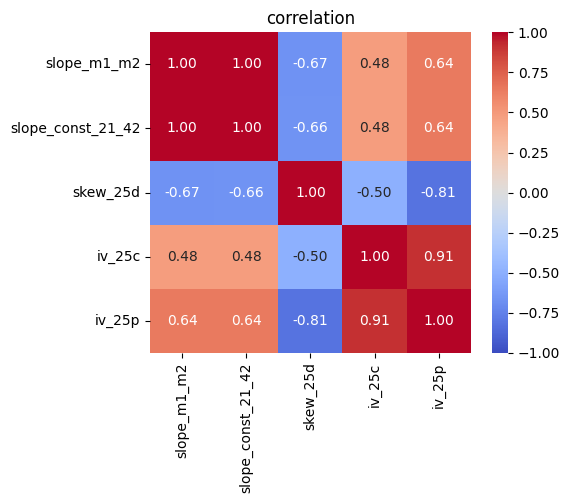

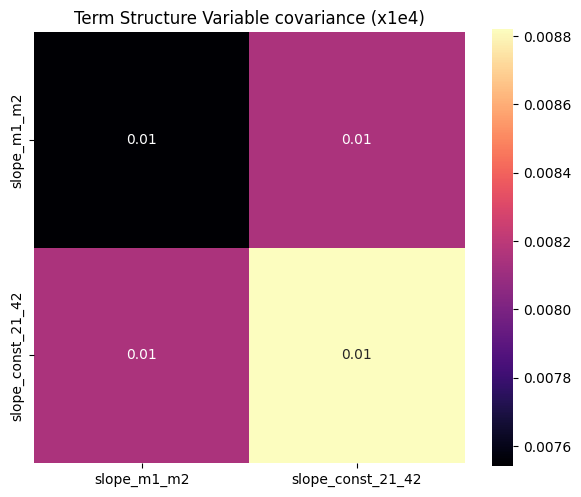

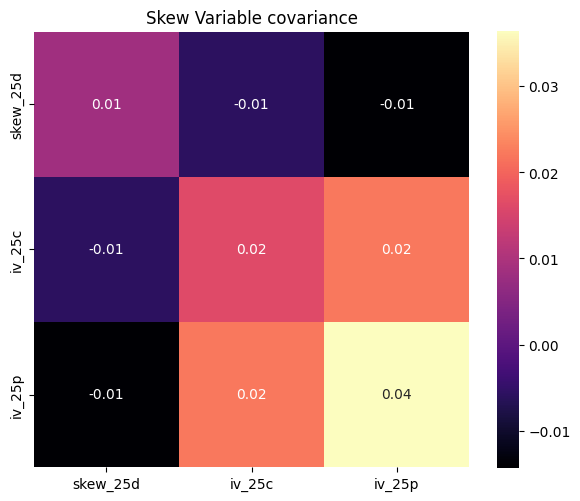

In [7]:
# correlation heatmap
plot_heatmap(data, cols=term_structure_cols + skew_cols, title="correlation", vmin=-1, vmax=1)

# covariance heatmap
cov = data[term_structure_cols].cov() * 1e4
plot_heatmap(data, matrix=cov, title=f"Term Structure Variable covariance (x1e4)", vmin=None, vmax=None, cmap="magma")

cov = data[skew_cols].cov()
plot_heatmap(data, matrix=cov, title=f"Skew Variable covariance", vmin=None, vmax=None, cmap="magma")


## Regression

In [8]:
res = fit_ols_sm(data, "skew_25d", ["slope_m1_m2"])
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:               skew_25d   R-squared:                       0.445
Model:                            OLS   Adj. R-squared:                  0.443
Method:                 Least Squares   F-statistic:                     386.6
Date:                Mon, 01 Dec 2025   Prob (F-statistic):           1.15e-63
Time:                        15:10:28   Log-Likelihood:                 613.54
No. Observations:                 485   AIC:                            -1223.
Df Residuals:                     483   BIC:                            -1215.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0627      0.003    -20.190      

- r-square is not too good, and given that there is not a super high correlation, the term structure is a meaningful but not exclusive driver of skew. This actually sets up the need for regressions and maybe some additional controls.